# EDA — Dacon E-Commerce Dataset

## 분석 목표
| 섹션 | 내용 |
|------|------|
| 1 | 데이터 개요 |
| 2 | 월별 매출 추이 |
| 3 | 카테고리 분석 |
| 4 | 인구통계 분석 |
| 5 | 쿠폰·할인 효과 |
| 6 | 마케팅 비용 분석 |
| 7 | 지역별 구매 패턴 |
| 8 | 요일별 구매 패턴 |
| 9 | 장바구니 분석 |
| 10 | EDA 인사이트 요약 |

---
## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()  # 프로젝트 루트의 .env 자동 탐색

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

---
## 1. 데이터 로드 및 기본 확인

In [2]:
df = pd.read_sql('SELECT * FROM orders_master', engine)
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,연도,...,할인적용여부,할인후금액,세후금액,성별,고객지역,가입기간,오프라인비용,온라인비용,최종결제금액,거래_총금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,1,138.34,152.17,남,Chicago,12,4500,2424.5,158.67,158.67
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,1,138.34,152.17,남,Chicago,12,4500,2424.5,158.67,158.67
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,2019,...,1,1.84,2.02,남,Chicago,12,4500,2424.5,8.52,8.52
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,2019,...,0,87.65,103.43,남,Chicago,12,4500,2424.5,109.93,833.50
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,2019,...,1,14.85,17.52,남,Chicago,12,4500,2424.5,24.02,833.50


In [3]:
df.shape

(52659, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52659 entries, 0 to 52658
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   고객ID    52659 non-null  object        
 1   거래ID    52659 non-null  object        
 2   거래날짜    52659 non-null  datetime64[ns]
 3   제품ID    52659 non-null  object        
 4   제품카테고리  52659 non-null  object        
 5   수량      52659 non-null  int64         
 6   평균금액    52659 non-null  float64       
 7   배송료     52659 non-null  float64       
 8   쿠폰상태    52659 non-null  object        
 9   연도      52659 non-null  int64         
 10  월       52659 non-null  int64         
 11  총매출     52659 non-null  float64       
 12  gst     52659 non-null  float64       
 13  쿠폰코드    52659 non-null  object        
 14  할인율     52659 non-null  int64         
 15  할인적용여부  52659 non-null  int64         
 16  할인후금액   52659 non-null  float64       
 17  세후금액    52659 non-null  float64       
 18  성별    

In [5]:
df.describe()

,거래날짜,수량,평균금액,배송료,연도,월,총매출,gst,할인율,할인적용여부,할인후금액,세후금액,가입기간,오프라인비용,온라인비용,최종결제금액,거래_총금액
count,52659,52659.000000,52659.000000,52659.000000,52659.0,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000,52659.000000
mean,2019-07-06 02:12:45.817809152,4.493515,52.447242,10.481560,2019.0,6.661748,88.405498,0.137407,19.950246,0.338461,82.493230,91.582166,26.133235,2831.918570,1893.903971,102.063726,338.370677
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000,2019.0,1.000000,0.400000,0.050000,10.000000,0.000000,0.290000,0.320000,2.000000,500.000000,320.250000,4.610000,6.400000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000,2019.0,4.000000,11.970000,0.100000,10.000000,0.000000,10.870000,12.630000,15.000000,2500.000000,1252.630000,20.160000,83.400000
50%,2019-07-14 00:00:00,1.000000,16.990000,6.000000,2019.0,7.000000,30.790000,0.180000,20.000000,0.000000,28.500000,33.040000,27.000000,3000.000000,1837.870000,45.640000,162.050000
75%,2019-09-27 00:00:00,2.000000,106.010000,6.500000,2019.0,9.000000,121.300000,0.180000,30.000000,1.000000,119.000000,130.900000,37.000000,3500.000000,2425.350000,137.400000,331.120000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000,2019.0,12.000000,10512.390000,0.180000,30.000000,1.000000,8545.500000,8972.780000,50.000000,5000.000000,4556.930000,8979.280000,22845.370000
std,NaN,20.135259,64.098031,19.335858,0.0,3.334553,164.101479,0.045850,8.126191,0.473191,154.386102,169.928262,13.475434,935.657542,807.107352,172.340825,957.807054


In [6]:
print(f"거래 기간: {df['거래날짜'].min().date()} ~ {df['거래날짜'].max().date()}")
print(f"고객 수: {df['고객ID'].nunique():,}명")
print(f"거래 수: {df['거래ID'].nunique():,}건")
print(f"제품 카테고리 수: {df['제품카테고리'].nunique()}개")
print(f"총 세후매출 합계: {df['세후금액'].sum():,.0f}")

거래 기간: 2019-01-01 ~ 2019-12-31
고객 수: 1,468명
거래 수: 25,036건
제품 카테고리 수: 18개
총 세후매출 합계: 4,822,625


---
## 2. 매출 트렌드 (월별)

In [7]:
monthly = pd.read_sql(
    """
    SELECT
        월,
        ROUND(SUM(세후금액), 0) AS 총매출,
        COUNT(DISTINCT 거래ID) AS 거래건수,
        COUNT(DISTINCT 고객ID) AS 고객수
    FROM orders_master
    GROUP BY 월
    ORDER BY 월
    """,
    engine
)
monthly

,월,총매출,거래건수,고객수
0,1,433807.0,2098,215
1,2,324183.0,1661,109
2,3,351107.0,1985,208
3,4,432006.0,1812,224
4,5,321690.0,2031,200
5,6,321526.0,1935,259
6,7,400428.0,2079,235
7,8,414108.0,2412,300
8,9,355317.0,1932,193
9,10,434763.0,2125,210


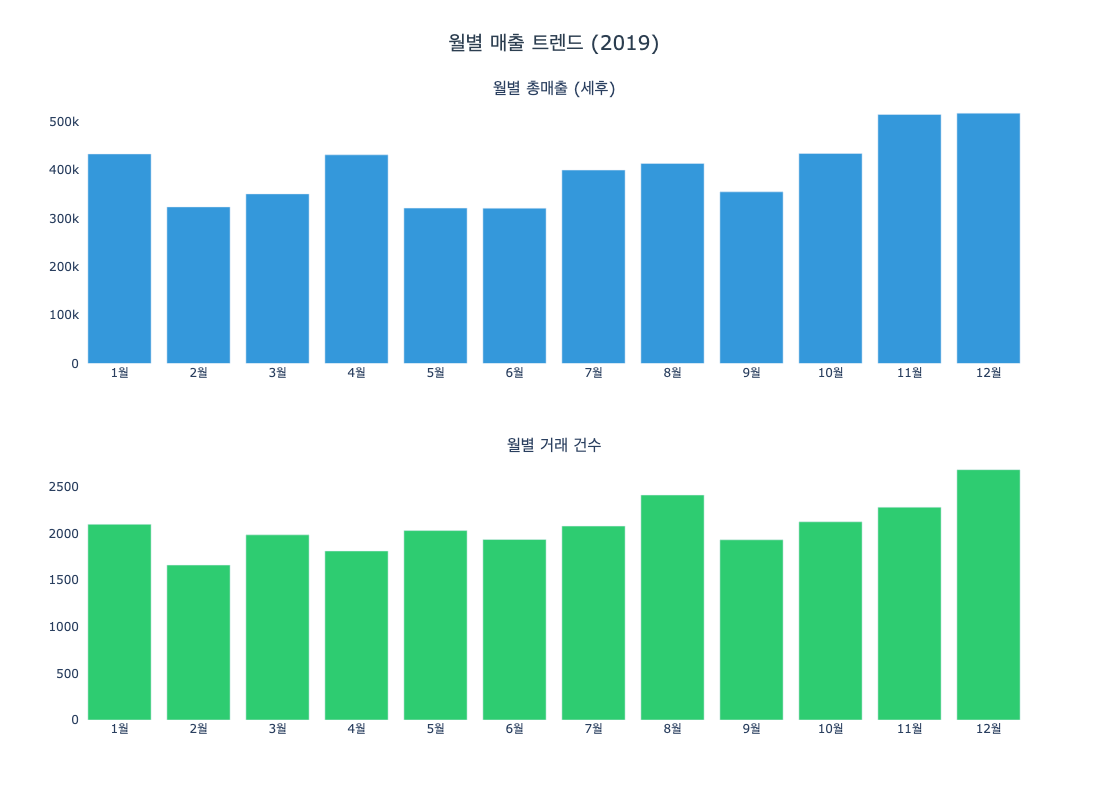

In [8]:
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['월별 총매출 (세후)', '월별 거래 건수'],
    vertical_spacing=0.15
)

fig.add_trace(go.Bar(
    x=monthly['월'], y=monthly['총매출'],
    marker_color='#3498db', name='총매출'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=monthly['월'], y=monthly['거래건수'],
    marker_color='#2ecc71', name='거래건수'
), row=2, col=1)

fig.update_layout(
    title=dict(text='월별 매출 트렌드 (2019)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=800
)

fig.update_xaxes(tickvals=list(range(1, 13)),
                 ticktext=['1월','2월','3월','4월','5월','6월',
                           '7월','8월','9월','10월','11월','12월'])

fig.show()

---
## 3. 카테고리별 분석

In [9]:
cat = pd.read_sql(
    """
    SELECT
        제품카테고리,
        ROUND(SUM(세후금액), 0) AS 총매출,
        COUNT(DISTINCT 거래ID) AS 거래건수,
        ROUND(AVG(평균금액), 2) AS 평균단가
    FROM orders_master
    GROUP BY 제품카테고리
    ORDER BY 총매출 DESC
    """,
    engine
)
cat

,제품카테고리,총매출,거래건수,평균단가
0,Nest-USA,2622006.0,11626,124.33
1,Apparel,650959.0,8129,19.79
2,Nest,504573.0,1974,194.22
3,Office,283500.0,3526,3.77
4,Drinkware,222492.0,2524,10.70
5,Bags,167982.0,1545,29.83
6,Notebooks & Journals,106610.0,620,11.76
7,Lifestyle,82038.0,1712,3.86
8,Nest-Canada,73343.0,258,157.24
9,Headgear,50398.0,674,15.88


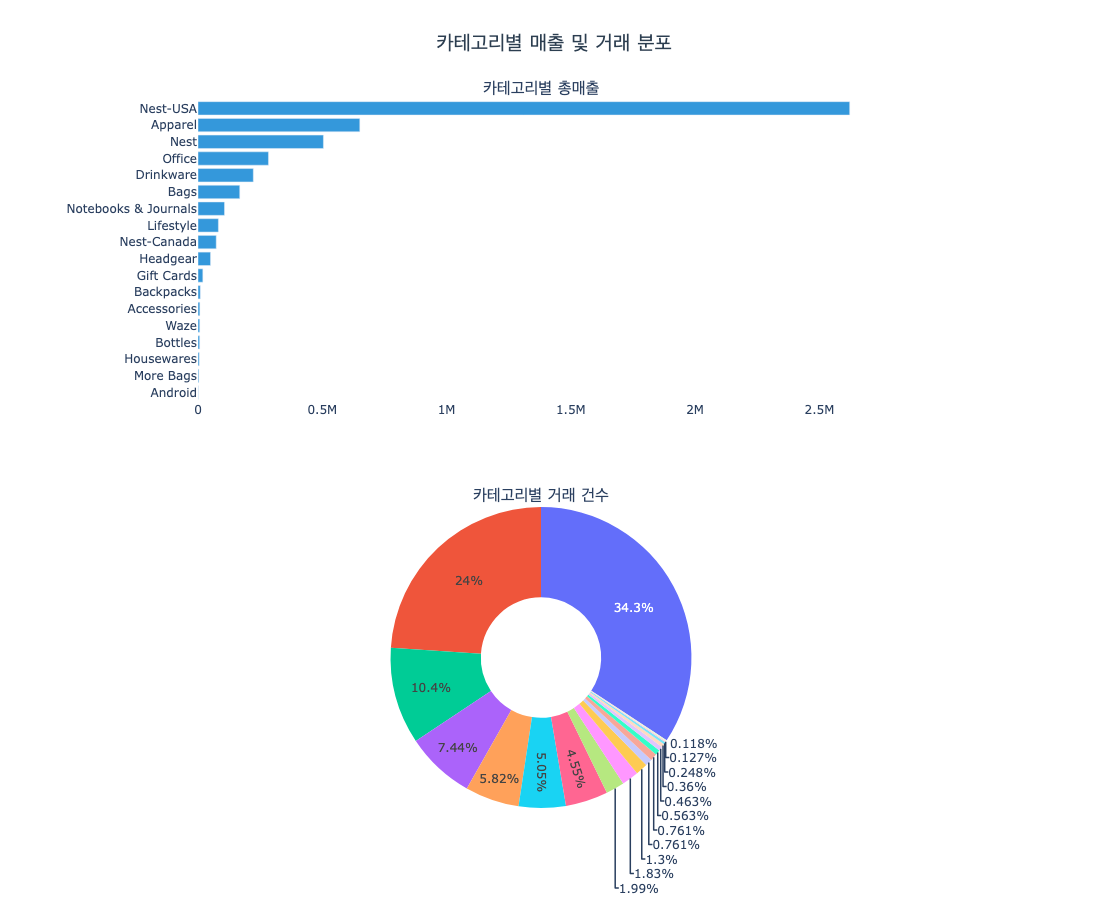

In [10]:
cat = cat.sort_values('총매출', ascending=True) 

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['카테고리별 총매출', '카테고리별 거래 건수'],
    specs=[[{'type': 'bar'}], [{'type': 'pie'}]],
    vertical_spacing=0.15
)

fig.add_trace(go.Bar(
    x=cat['총매출'], y=cat['제품카테고리'],
    orientation='h', marker_color='#3498db', name='총매출'
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=cat['제품카테고리'], values=cat['거래건수'],
    hole=0.4, name='거래건수'
), row=2, col=1)

fig.update_layout(
    title=dict(text='카테고리별 매출 및 거래 분포', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=900
)

fig.show()

In [11]:
# 인기 기준은 거래량 순으로 판단
product_top = pd.read_sql(
    """
    WITH cat_top5 AS (
        SELECT 제품카테고리
        FROM orders_master
        GROUP BY 제품카테고리
        ORDER BY COUNT(DISTINCT 거래ID) DESC
        LIMIT 5
    ),
    product_stats AS (
        SELECT
            o.제품카테고리,
            o.제품ID,
            COUNT(o.거래ID) AS 거래건수,
            ROUND(SUM(o.세후금액), 0) AS 총매출
        FROM orders_master o
        JOIN cat_top5 c ON o.제품카테고리 = c.제품카테고리
        GROUP BY o.제품카테고리, o.제품ID
    ),
    ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY 제품카테고리
                   ORDER BY 거래건수 DESC
               ) AS rn
        FROM product_stats
    )
    SELECT 제품카테고리, 제품ID, 거래건수, 총매출
    FROM ranked
    WHERE rn <= 5
    ORDER BY 제품카테고리, 거래건수 DESC
    """,
    engine
)
top_cats = product_top['제품카테고리'].unique().tolist()
product_top

,제품카테고리,제품ID,거래건수,총매출
0,Apparel,Product_0922,546,22812.0
1,Apparel,Product_0228,216,2837.0
2,Apparel,Product_0206,186,2933.0
3,Apparel,Product_1137,182,12026.0
4,Apparel,Product_0295,160,7712.0
5,Drinkware,Product_0880,583,29480.0
6,Drinkware,Product_0892,408,36695.0
7,Drinkware,Product_0894,319,13661.0
8,Drinkware,Product_0900,315,14739.0
9,Drinkware,Product_0908,292,8066.0


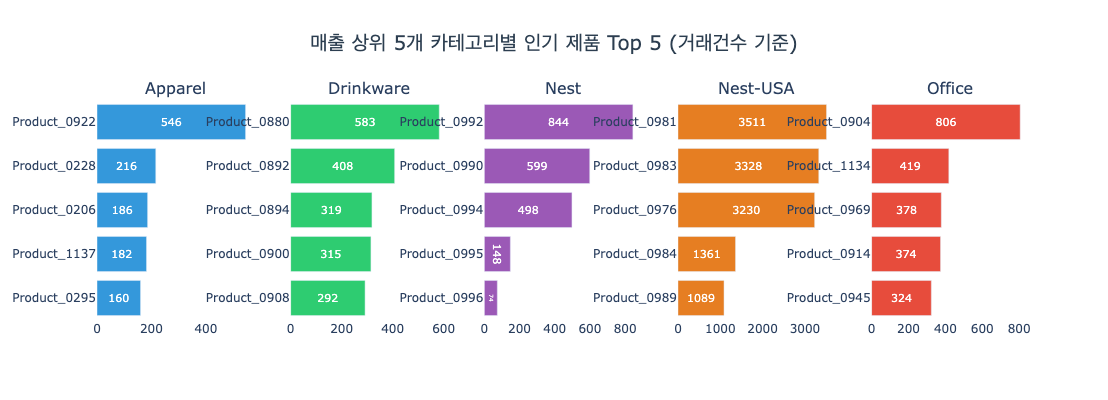

In [12]:
fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=top_cats,
    shared_yaxes=False
)

colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

for i, cat_name in enumerate(top_cats):
    data = product_top[product_top['제품카테고리'] == cat_name].sort_values('거래건수')
    fig.add_trace(go.Bar(
        x=data['거래건수'],
        y=data['제품ID'],
        orientation='h',
        marker_color=colors[i],
        name=cat_name,
        text=data['거래건수'],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(size=11, color='white')
    ), row=1, col=i+1)

fig.update_layout(
    title=dict(text='매출 상위 5개 카테고리별 인기 제품 Top 5 (거래건수 기준)',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=400,
    width=1500
)

fig.show()

---
## 4. 고객 인구통계 분석

In [13]:
total_customers = df['고객ID'].nunique()
print(f"전체 고유 고객 수: {total_customers:,}명")

전체 고유 고객 수: 1,468명


In [14]:
gender = pd.read_sql(
    """
    SELECT
        성별,
        ROUND(SUM(세후금액), 0) AS 총매출,
        COUNT(DISTINCT 고객ID) AS 고객수,
        ROUND(AVG(세후금액), 2) AS 평균구매액
    FROM orders_master
    GROUP BY 성별
    """,
    engine
)
gender

,성별,총매출,고객수,평균구매액
0,남,1818930.0,534,91.80
1,여,3003695.0,934,91.45


In [15]:
region = pd.read_sql(
    """
    SELECT
        고객지역,
        ROUND(SUM(세후금액), 0) AS 총매출,
        COUNT(DISTINCT 고객ID) AS 고객수
    FROM orders_master
    GROUP BY 고객지역
    ORDER BY 총매출 DESC
    """,
    engine
)
region

,고객지역,총매출,고객수
0,Chicago,1676209.0,456
1,California,1490695.0,464
2,New York,966844.0,324
3,New Jersey,422520.0,149
4,Washington DC,266357.0,75


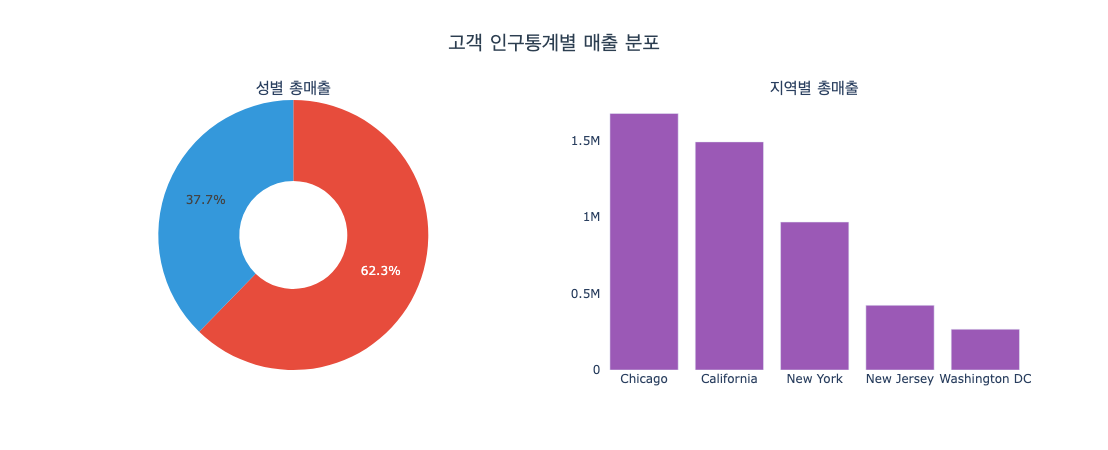

In [16]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['성별 총매출', '지역별 총매출'],
    specs=[[{'type': 'pie'}, {'type': 'bar'}]]
)

fig.add_trace(go.Pie(
    labels=gender['성별'], values=gender['총매출'],
    hole=0.4, name='성별',
    marker=dict(colors=['#3498db', '#e74c3c'])
), row=1, col=1)

fig.add_trace(go.Bar(
    x=region['고객지역'], y=region['총매출'],
    marker_color='#9b59b6', name='지역별'
), row=1, col=2)

fig.update_layout(
    title=dict(text='고객 인구통계별 매출 분포', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=450
)

fig.show()

In [17]:
tenure = pd.read_sql(
    """
    WITH cust_level AS (
        SELECT
            고객ID,
            CASE
                WHEN MAX(가입기간) BETWEEN 1  AND 12 THEN '0~12개월'
                WHEN MAX(가입기간) BETWEEN 13 AND 24 THEN '13~24개월'
                ELSE '25개월 이상'
            END AS 가입기간_구간,
            COUNT(DISTINCT 거래ID) AS 구매빈도
        FROM orders_master
        GROUP BY 고객ID
    ),
    group_stats AS (
        SELECT
            CASE
                WHEN 가입기간 BETWEEN 1  AND 12 THEN '0~12개월'
                WHEN 가입기간 BETWEEN 13 AND 24 THEN '13~24개월'
                ELSE '25개월 이상'
            END AS 가입기간_구간,
            COUNT(DISTINCT 고객ID) AS 고객수,
            ROUND(AVG(세후금액), 2) AS 평균구매액,
            ROUND(AVG(할인적용여부) * 100, 1) AS 쿠폰사용률
        FROM orders_master
        GROUP BY 가입기간_구간
    ),
    freq_stats AS (
        SELECT 가입기간_구간, ROUND(AVG(구매빈도), 2) AS 구매빈도
        FROM cust_level
        GROUP BY 가입기간_구간
    )
    SELECT g.가입기간_구간, g.고객수, g.평균구매액, g.쿠폰사용률, f.구매빈도
    FROM group_stats g
    JOIN freq_stats f ON g.가입기간_구간 = f.가입기간_구간
    ORDER BY
        CASE g.가입기간_구간
            WHEN '0~12개월' THEN 1
            WHEN '13~24개월' THEN 2
            ELSE 3
        END
    """,
    engine
)
tenure

,가입기간_구간,고객수,평균구매액,쿠폰사용률,구매빈도
0,0~12개월,327,92.07,33.4,17.62
1,13~24개월,361,88.63,34.0,16.94
2,25개월 이상,780,92.62,34.0,18.88


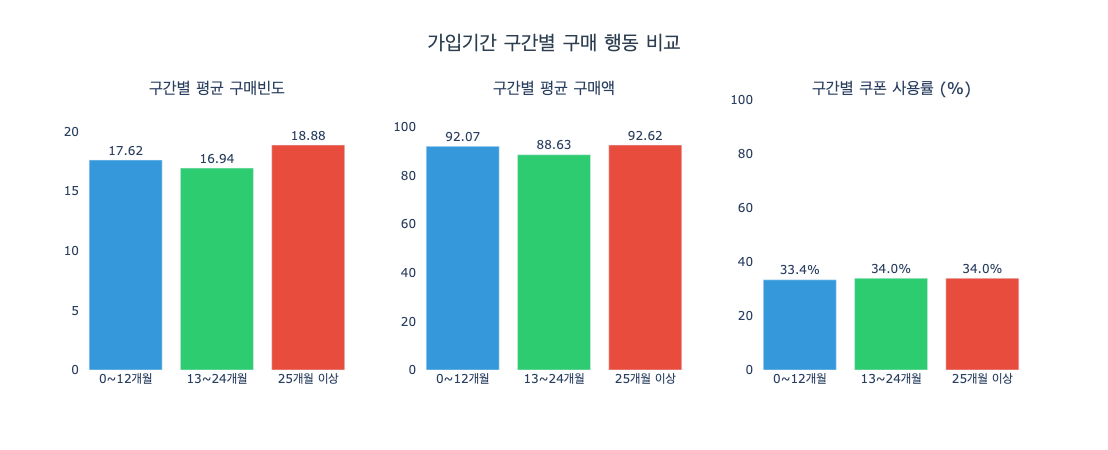

In [18]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['구간별 평균 구매빈도', '구간별 평균 구매액', '구간별 쿠폰 사용률 (%)']
)

color = ['#3498db', '#2ecc71', '#e74c3c']

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['구매빈도'],
    marker_color=color, text=tenure['구매빈도'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['평균구매액'],
    marker_color=color, text=tenure['평균구매액'], textposition='outside'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['쿠폰사용률'],
    marker_color=color, text=tenure['쿠폰사용률'].astype(str) + '%', textposition='outside'
), row=1, col=3)

fig.update_layout(
    title=dict(text='가입기간 구간별 구매 행동 비교', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=450
)

fig.update_yaxes(range=[0, tenure['구매빈도'].max() * 1.2], row=1, col=1)
fig.update_yaxes(range=[0, tenure['평균구매액'].max() * 1.2], row=1, col=2)
fig.update_yaxes(range=[0, 100], row=1, col=3) 

fig.show()

### 고객별 거래 건수 분포

1년간 고객 1인당 거래 건수의 분포를 확인한다.

In [19]:
# 고객별 거래 건수 분포
purchase_freq = pd.read_sql(
    """
    SELECT
        COUNT(DISTINCT 거래ID) AS 거래건수
    FROM orders_master
    GROUP BY 고객ID
    ORDER BY 거래건수
    """,
    engine
)
purchase_freq.describe().round(1)

,거래건수
count,1468.0
mean,18.1
std,24.9
min,1.0
25%,5.0
50%,11.0
75%,23.0
max,327.0


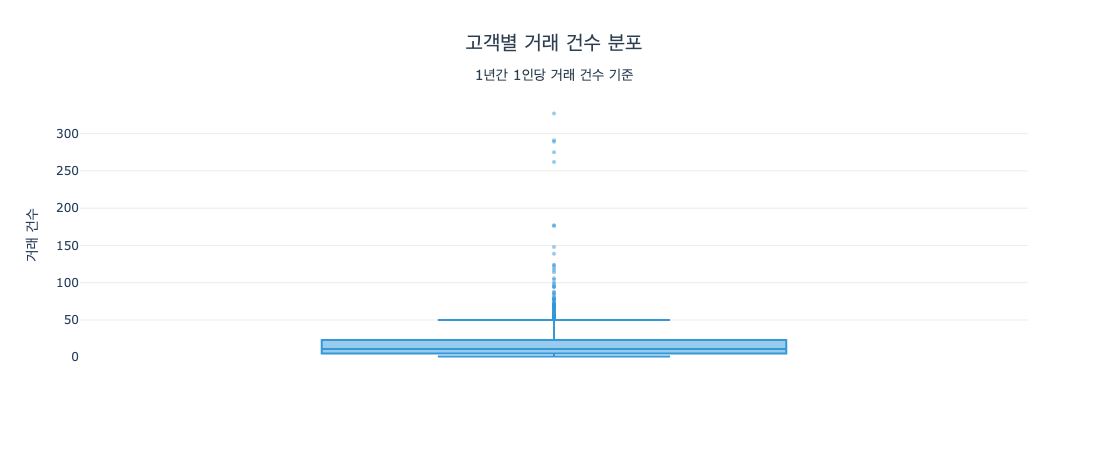

In [20]:
fig = go.Figure(go.Box(
    y=purchase_freq["거래건수"],
    boxpoints="outliers",
    marker=dict(color="#3498db", size=4, opacity=0.5),
    line=dict(color="#3498db"),
    name=""
))

fig.update_layout(
    title=dict(
        text="고객별 거래 건수 분포<br><sub>1년간 1인당 거래 건수 기준</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    yaxis_title="거래 건수",
    plot_bgcolor="white",
    xaxis=dict(showticklabels=False),
    yaxis=dict(gridcolor="#ececec"),
    height=450
)
fig.show()

- 중앙값 **11건**, 평균 **18.1건** — 평균이 중앙값보다 높아 소수의 헤비유저가 평균을 끌어올리는 우편향 분포
- **75%의 고객이 23건 이하**로 구매 빈도가 낮은 고객이 대부분을 차지
- 최댓값 **327건**으로 극단적인 헤비유저가 존재하며, 이상치 점들이 다수 분포

### 고객별 재방문 횟수 분포

거래 건수가 아닌 **구매일 수 기준**으로 재방문 횟수를 집계한다.  
같은 날 여러 번 구매한 경우 1회 방문으로 처리한다.

In [21]:
revisit_freq = pd.read_sql(
    """
    SELECT
        COUNT(DISTINCT DATE(거래날짜)) - 1 AS 재방문횟수
    FROM orders_master
    GROUP BY 고객ID
    ORDER BY 재방문횟수
    """,
    engine
)
revisit_freq.describe().round(1)

,재방문횟수
count,1468.0
mean,1.2
std,2.2
min,0.0
25%,0.0
50%,0.5
75%,2.0
max,33.0


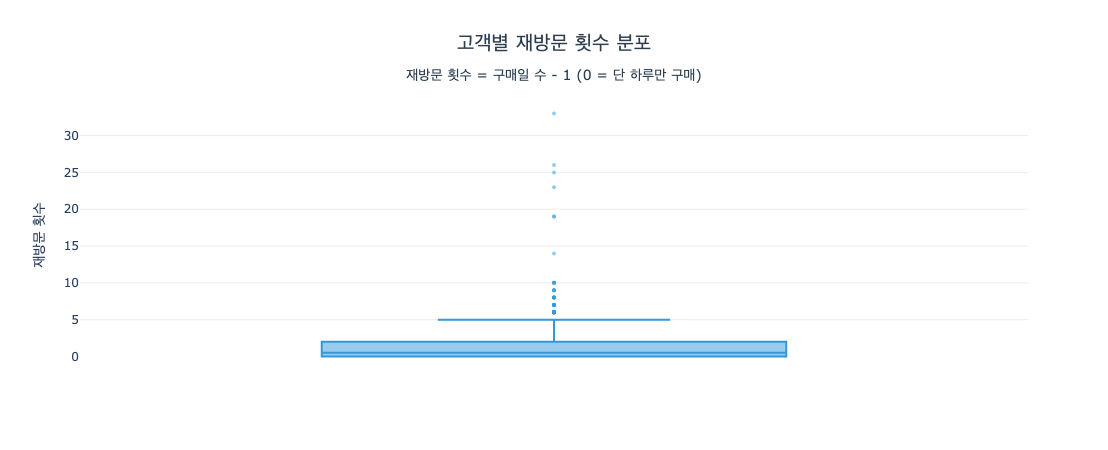

In [22]:
fig = go.Figure(go.Box(
    y=revisit_freq["재방문횟수"],
    boxpoints="outliers",
    marker=dict(color="#3498db", size=4, opacity=0.5),
    line=dict(color="#3498db"),
    name=""
))

fig.update_layout(
    title=dict(
        text="고객별 재방문 횟수 분포<br><sub>재방문 횟수 = 구매일 수 - 1 (0 = 단 하루만 구매)</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    yaxis_title="재방문 횟수",
    plot_bgcolor="white",
    xaxis=dict(showticklabels=False),
    yaxis=dict(gridcolor="#ececec"),
    height=450
)
fig.show()

### 성별 구매 패턴

성별로 구매금액 중앙값을 비교하고, 각 성별에서 가장 자주 구매한 카테고리를 확인한다.

In [23]:
# 성별 구매금액 통계 (중앙값·평균)
gender_stats = (
    df.groupby("성별")["세후금액"]
    .agg(["mean", "median"])
    .round(2)
    .rename(columns={"mean": "평균", "median": "중앙값"})
    .reset_index()
)

# 성별 × 카테고리 중앙값
gender_cat_median = (
    df.groupby(["성별", "제품카테고리"])["세후금액"]
    .median()
    .round(2)
    .unstack("성별")
    .reset_index()
    .rename(columns={"남": "남성_중앙값", "여": "여성_중앙값"})
)


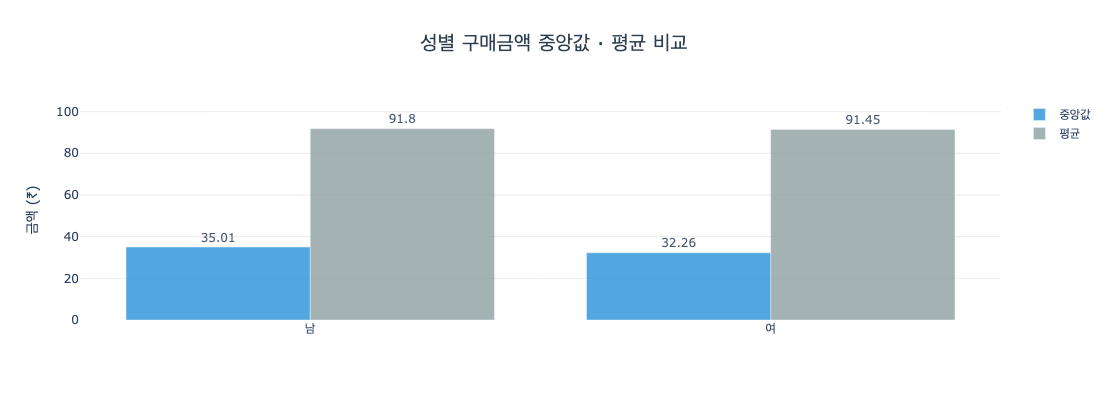

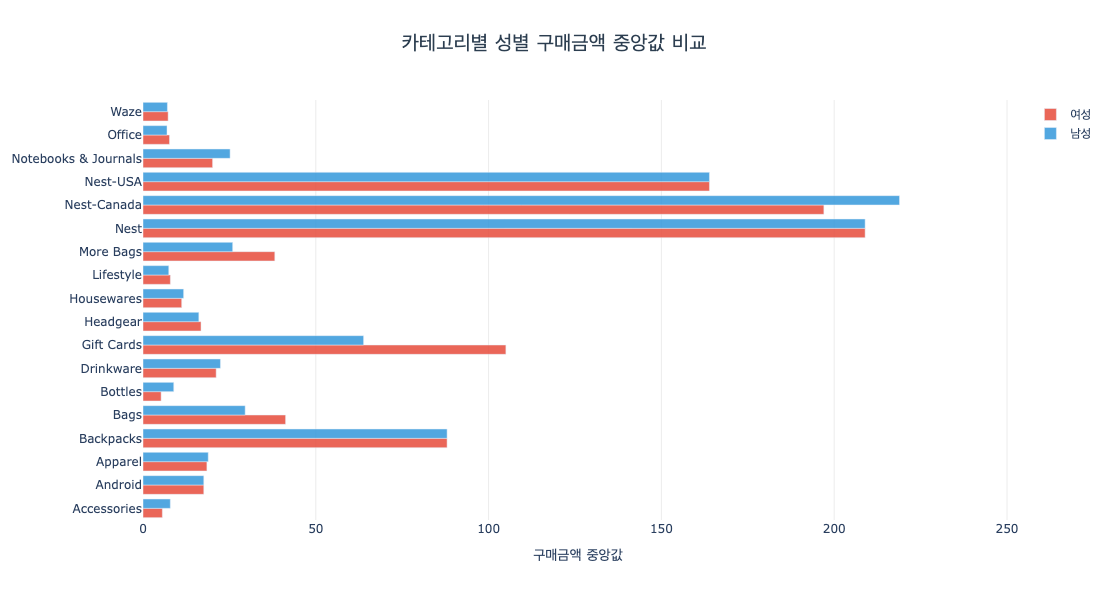

In [24]:
# ── 차트 1: 성별 구매금액 중앙값 · 평균 비교 ──
y_max1 = gender_stats[["중앙값", "평균"]].max().max() * 1.15

fig1 = go.Figure()
for metric, color in [("중앙값", "#3498db"), ("평균", "#95a5a6")]:
    fig1.add_trace(go.Bar(
        x=gender_stats["성별"],
        y=gender_stats[metric],
        name=metric,
        marker_color=color,
        text=gender_stats[metric],
        textposition="outside",
        opacity=0.85
    ))
    
fig1.update_layout(
    title=dict(text="성별 구매금액 중앙값 · 평균 비교",
               x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
    barmode="group",
    yaxis_title="금액 (₹)",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#ececec", range=[0, y_max1]),
    height=400
)

fig1.show()

# ── 차트 2: 카테고리별 성별 중앙값 비교 ──
cats = gender_cat_median["제품카테고리"].tolist()
x_max2 = gender_cat_median[["남성_중앙값", "여성_중앙값"]].max().max() * 1.15

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=cats, x=gender_cat_median["여성_중앙값"],
    name="여성", orientation="h",
    marker_color="#e74c3c", opacity=0.85
))

fig2.add_trace(go.Bar(
    y=cats, x=gender_cat_median["남성_중앙값"],
    name="남성", orientation="h",
    marker_color="#3498db", opacity=0.85
))

fig2.update_layout(
    title=dict(text="카테고리별 성별 구매금액 중앙값 비교",
               x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
    barmode="group",
    xaxis_title="구매금액 중앙값",
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#ececec", range=[0, x_max2]),
    height=600
)
fig2.show()


---
## 5. 쿠폰/할인 효과 분석

In [25]:
coupon = pd.read_sql(
    """
    SELECT
        쿠폰상태,
        COUNT(거래ID) AS 건수,
        ROUND(AVG(세후금액), 2) AS 평균구매액,
        ROUND(SUM(세후금액), 0) AS 총매출
    FROM orders_master
    GROUP BY 쿠폰상태
    """,
    engine
)
coupon

,쿠폰상태,건수,평균구매액,총매출
0,Used,17823,77.43,1380037.0
1,Not Used,8044,100.63,809467.0
2,Clicked,26792,98.28,2633121.0


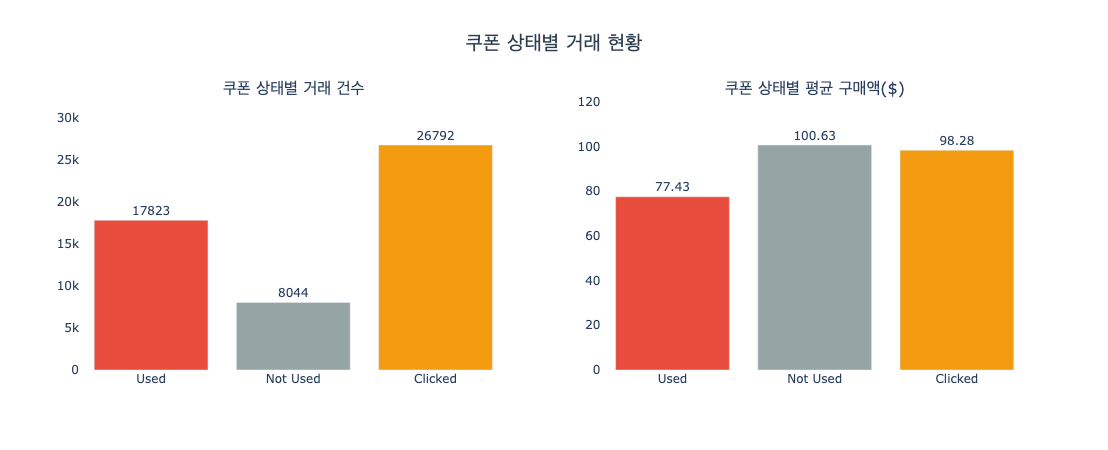

In [26]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['쿠폰 상태별 거래 건수', '쿠폰 상태별 평균 구매액($)']
)

colors = {'Used': '#e74c3c', 'Clicked': '#f39c12', 'Not Used': '#95a5a6'}
c_colors = [colors[s] for s in coupon['쿠폰상태']]

fig.add_trace(go.Bar(
    x=coupon['쿠폰상태'], y=coupon['건수'],
    marker_color=c_colors, 
    text=coupon['건수'], 
    textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=coupon['쿠폰상태'], y=coupon['평균구매액'].round(2),
    marker_color=c_colors, 
    text=coupon['평균구매액'].round(2), 
    textposition='outside'
), row=1, col=2)

fig.update_layout(
    title=dict(text='쿠폰 상태별 거래 현황', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=450
)

fig.update_yaxes(range=[0, coupon['건수'].max() * 1.2], row=1, col=1)
fig.update_yaxes(range=[0, coupon['평균구매액'].max() * 1.2], row=1, col=2)

fig.show()

In [27]:
discount_grp = pd.read_sql(
    """
    SELECT
        할인율,
        COUNT(거래ID) AS 건수,
        ROUND(AVG(세후금액), 2) AS 평균구매액
    FROM orders_master
    WHERE 할인적용여부 = 1
    GROUP BY 할인율
    ORDER BY 할인율
    """,
    engine
)
discount_grp

,할인율,건수,평균구매액
0,10,5949,87.55
1,20,6018,75.26
2,30,5856,69.38


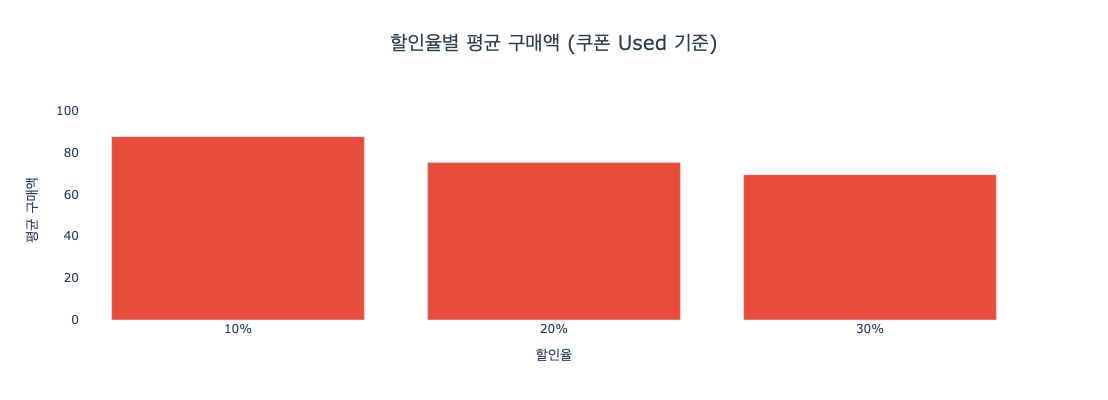

In [28]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=discount_grp['할인율'].astype(str) + '%',
    y=discount_grp['평균구매액'].round(2),
    marker_color='#e74c3c'
))

fig.update_layout(
    title=dict(text='할인율별 평균 구매액 (쿠폰 Used 기준)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='할인율',
    yaxis_title='평균 구매액',
    plot_bgcolor='white',
    width=400,
    height=400
)

fig.update_yaxes(range=[0, discount_grp['평균구매액'].max() * 1.2])

fig.show()

---
## 6. 마케팅 비용 분석

In [29]:
marketing_monthly = pd.read_sql(
    """
    SELECT
        월,
        ROUND(SUM(세후금액), 0) AS 총매출,
        ROUND(AVG(오프라인비용), 0) AS 오프라인비용,
        ROUND(AVG(온라인비용), 0) AS 온라인비용
    FROM orders_master
    GROUP BY 월
    ORDER BY 월
    """,
    engine
)
marketing_monthly['총마케팅비용'] = marketing_monthly['오프라인비용'] + marketing_monthly['온라인비용']
marketing_monthly['ROI'] = (marketing_monthly['총매출'] / marketing_monthly['총마케팅비용']).round(2)
marketing_monthly

,월,총매출,오프라인비용,온라인비용,총마케팅비용,ROI
0,1,433807.0,3043.0,1892.0,4935.0,87.90
1,2,324183.0,2888.0,1938.0,4826.0,67.17
2,3,351107.0,2413.0,1603.0,4016.0,87.43
3,4,432006.0,3242.0,1975.0,5217.0,82.81
4,5,321690.0,2177.0,1656.0,3833.0,83.93
5,6,321526.0,2669.0,1773.0,4442.0,72.38
6,7,400428.0,2201.0,1726.0,3927.0,101.97
7,8,414108.0,2739.0,1878.0,4617.0,89.69
8,9,355317.0,2772.0,1719.0,4491.0,79.12
9,10,434763.0,3056.0,1877.0,4933.0,88.13


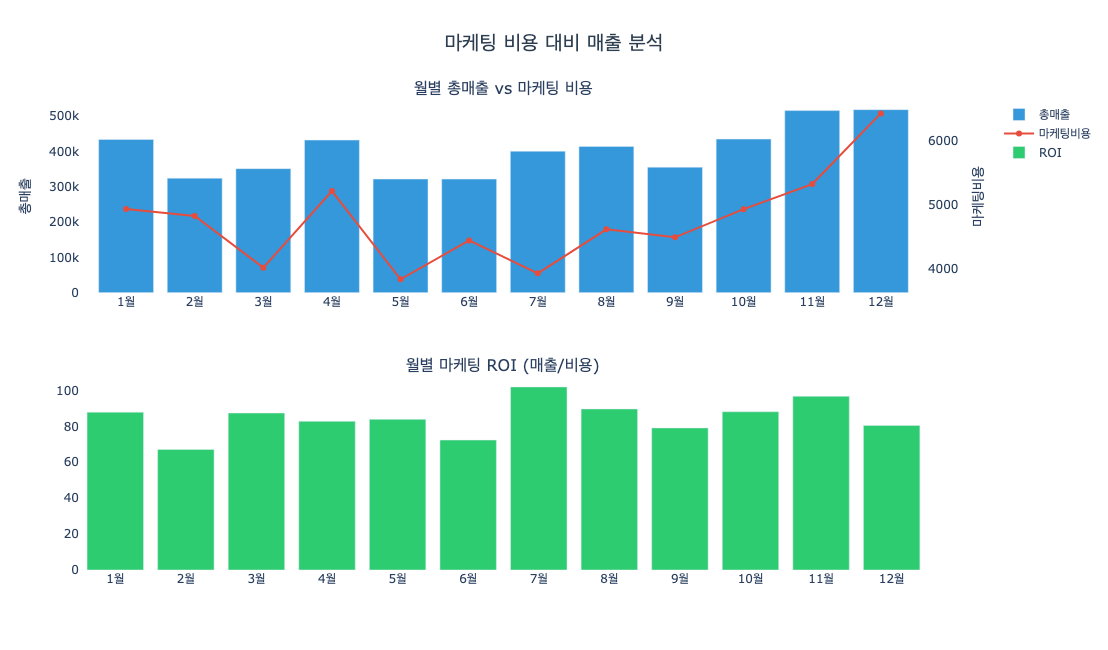

In [30]:
월_labels = []

for i in range(0, 12):
    월_labels.append(str(i+1) + '월')

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['월별 총매출 vs 마케팅 비용', '월별 마케팅 ROI (매출/비용)'],
    specs=[[{"secondary_y": True}], [{"secondary_y": False}]],
    vertical_spacing=0.18
)

fig.add_trace(go.Bar(
    x=marketing_monthly['월'], y=marketing_monthly['총매출'],
    name='총매출', marker_color='#3498db'
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=marketing_monthly['월'], y=marketing_monthly['총마케팅비용'],
    name='마케팅비용', mode='lines+markers',
    line=dict(color='#e74c3c', width=2), marker=dict(size=6)
), row=1, col=1, secondary_y=True)

fig.add_trace(go.Bar(
    x=marketing_monthly['월'], y=marketing_monthly['ROI'],
    name='ROI', marker_color='#2ecc71'
), row=2, col=1)

fig.update_yaxes(title_text='총매출', secondary_y=False, row=1, col=1)
fig.update_yaxes(title_text='마케팅비용', secondary_y=True, row=1, col=1)

fig.update_layout(
    title=dict(text='마케팅 비용 대비 매출 분석', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    height=650,
    showlegend=True
)

fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=월_labels)
fig.show()

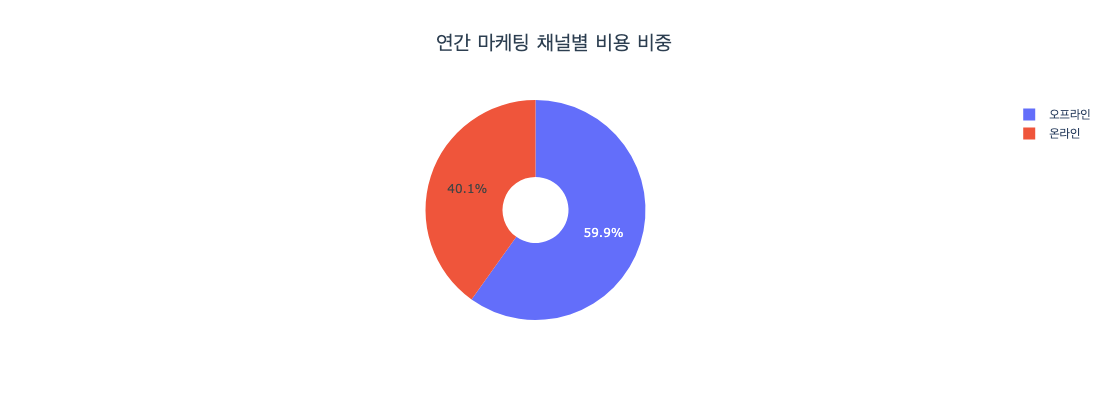

In [31]:
daily = df.drop_duplicates('거래날짜')[['거래날짜', '오프라인비용', '온라인비용']]
offline_total = daily['오프라인비용'].sum()
online_total = daily['온라인비용'].sum()

fig = go.Figure(go.Pie(
    labels=['오프라인', '온라인'],
    values=[offline_total, online_total],
    hole=0.3
))

fig.update_layout(
    title=dict(text='연간 마케팅 채널별 비용 비중', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    height=400
)

fig.show()

In [32]:
corr = marketing_monthly[['총매출', '온라인비용', '오프라인비용']].corr().round(2)
corr

,총매출,온라인비용,오프라인비용
총매출,1.00,0.83,0.72
온라인비용,0.83,1.00,0.88
오프라인비용,0.72,0.88,1.00


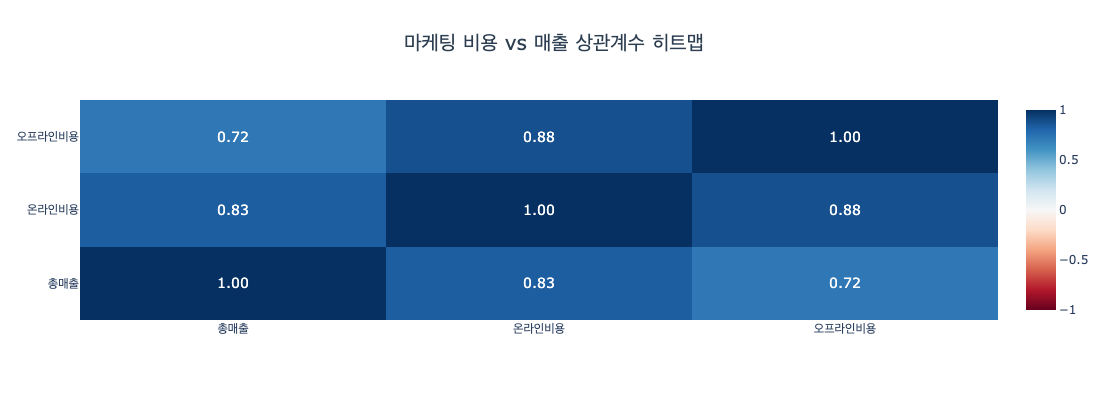

In [33]:
labels = ['총매출', '온라인비용', '오프라인비용']
z = corr.values

fig = go.Figure(go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    colorscale='RdBu',
    zmin=-1, zmax=1,
    text=[[f'{v:.2f}' for v in row] for row in z],
    texttemplate='%{text}',
    textfont=dict(size=14),
    showscale=True
))

fig.update_layout(
    title=dict(text='마케팅 비용 vs 매출 상관계수 히트맵', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    height=400,
    width=500
)
fig.show()

### ARPPU 분석

마케팅 데이터를 분석하기에 앞서 아래와 같은 가정을 전제로 진행하였다.

> **마케팅을 진행한 날짜부터 14일까지의 구매이력이 모두 광고 영향을 어느정도 받았다고 가정하였으며,  
> 마찬가지로 마케팅을 진행한 날짜부터 14일이 지난 후의 구매데이터는 해당 마케팅과 연관이 없다고 가정하였다.**

단, 2019-12-18 이후 광고일은 14일 윈도우가 연도를 벗어나므로 분석에서 제외하였다.

In [34]:
# 광고일 기준 14일 윈도우 ARPPU 계산
# 2019-12-18 이후는 14일 윈도우가 연도를 벗어나므로 제외
mar_dates = (
    df[['거래날짜', '오프라인비용', '온라인비용']]
    .drop_duplicates('거래날짜')
    .query("거래날짜 <= '2019-12-17'")
    .reset_index(drop=True)
)

rows = []
for _, row in mar_dates.iterrows():
    start = row['거래날짜']
    end = start + pd.Timedelta(days=14)
    window = df[(df['거래날짜'] >= start) & (df['거래날짜'] <= end)]
    rows.append({
        '날짜': start,
        '오프라인비용': row['오프라인비용'],
        '온라인비용': row['온라인비용'],
        '총마케팅비용': row['오프라인비용'] + row['온라인비용'],
        '+14일_누적매출': window['세후금액'].sum(),
        '+14일_누적고객': window['고객ID'].nunique()
    })

daily_mkt = pd.DataFrame(rows)

print(f"분석 대상 광고일: {len(daily_mkt)}일 (2019-01-01 ~ 2019-12-17)")

분석 대상 광고일: 351일 (2019-01-01 ~ 2019-12-17)


In [35]:
daily_mkt.head()

,날짜,오프라인비용,온라인비용,총마케팅비용,+14일_누적매출,+14일_누적고객
0,2019-01-01,4500,2424.50,6924.50,204178.79,93
1,2019-01-02,4500,3480.36,7980.36,208815.49,95
2,2019-01-03,4500,1576.38,6076.38,213541.03,98
3,2019-01-04,4500,2928.55,7428.55,209938.10,94
4,2019-01-05,4500,4055.30,8555.30,205569.13,94


In [36]:
daily_mkt['ARPPU'] = daily_mkt['+14일_누적매출'] / daily_mkt['+14일_누적고객']
daily_mkt[['날짜', '+14일_누적고객', '+14일_누적매출', 'ARPPU']].head()

,날짜,+14일_누적고객,+14일_누적매출,ARPPU
0,2019-01-01,93,204178.79,2195.470860
1,2019-01-02,95,208815.49,2198.057789
2,2019-01-03,98,213541.03,2178.990102
3,2019-01-04,94,209938.10,2233.384043
4,2019-01-05,94,205569.13,2186.905638


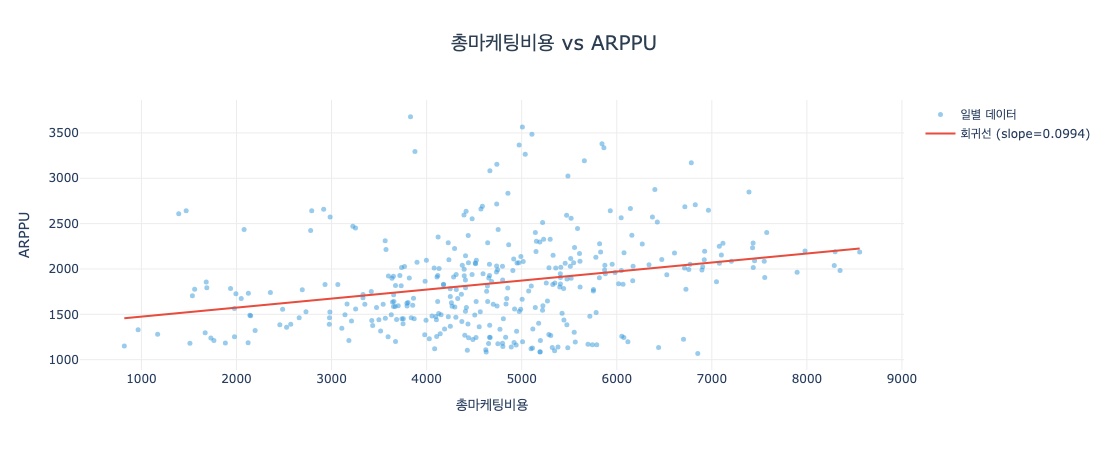

In [37]:
from scipy import stats

slope_total, intercept_total, *_ = stats.linregress(daily_mkt['총마케팅비용'], daily_mkt['ARPPU'])
x_line = np.linspace(daily_mkt['총마케팅비용'].min(), daily_mkt['총마케팅비용'].max(), 100)
y_line = slope_total * x_line + intercept_total

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily_mkt['총마케팅비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#3498db', size=5, opacity=0.5),
    name='일별 데이터'
))
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines', line=dict(color='#e74c3c', width=2),
    name=f'회귀선 (slope={slope_total:.4f})'
))
fig.update_layout(
    title=dict(text='총마케팅비용 vs ARPPU', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='총마케팅비용', yaxis_title='ARPPU',
    plot_bgcolor='white', width=900, height=450
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.show()

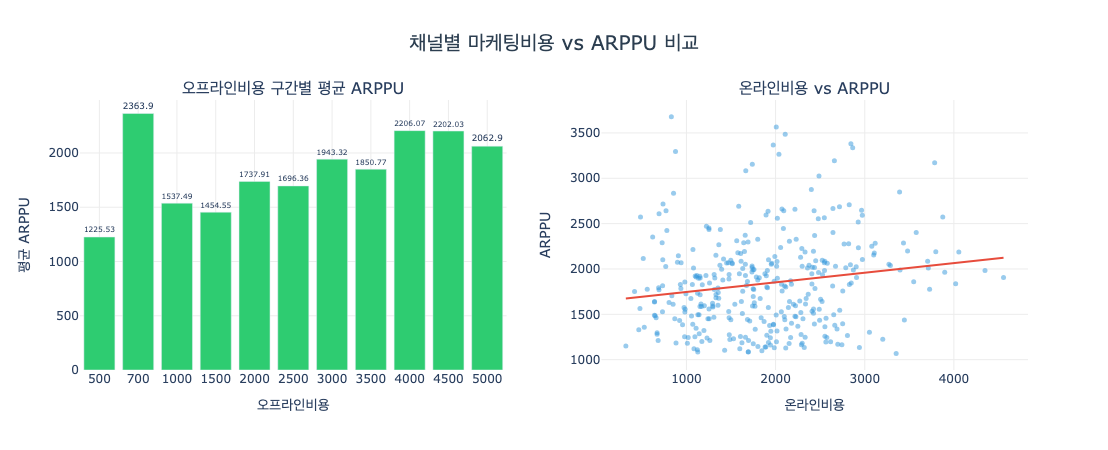

In [38]:
# 오프라인: 비용 구간별 평균 ARPPU
offline_avg = daily_mkt.groupby('오프라인비용')['ARPPU'].mean().reset_index()
offline_avg['ARPPU'] = offline_avg['ARPPU'].round(2)

# 온라인: 회귀선
slope_online, intercept_online, *_ = stats.linregress(daily_mkt['온라인비용'], daily_mkt['ARPPU'])
x_on = np.linspace(daily_mkt['온라인비용'].min(), daily_mkt['온라인비용'].max(), 100)
y_on = slope_online * x_on + intercept_online

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '오프라인비용 구간별 평균 ARPPU',
        f'온라인비용 vs ARPPU'
    ]
)

fig.add_trace(go.Bar(
    x=offline_avg['오프라인비용'].astype(str),
    y=offline_avg['ARPPU'],
    marker_color='#2ecc71',
    text=offline_avg['ARPPU'],
    textposition='outside',
    name='오프라인'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_mkt['온라인비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#3498db', size=5, opacity=0.5),
    name='온라인 데이터'
), row=1, col=2)
fig.add_trace(go.Scatter(
    x=x_on, y=y_on,
    mode='lines', line=dict(color='#e74c3c', width=2),
    name='회귀선'
), row=1, col=2)

fig.update_layout(
    title=dict(text='채널별 마케팅비용 vs ARPPU 비교', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', height=450, showlegend=False
)
fig.update_xaxes(title_text='오프라인비용', row=1, col=1, gridcolor='#ececec')
fig.update_yaxes(title_text='평균 ARPPU', row=1, col=1, gridcolor='#ececec')
fig.update_xaxes(title_text='온라인비용', row=1, col=2, gridcolor='#ececec')
fig.update_yaxes(title_text='ARPPU', row=1, col=2, gridcolor='#ececec')
fig.show()

#### 온/오프라인 중 더 효과적인 마케팅 방법 선택

>온라인과 오프라인 마케팅 중 ARPPU를 올리기 위해 더 효율적인 채널이 무엇인지 알아보기 위해,  
두 채널의 비용 vs ARPPU 회귀선을 구한 후 **기울기(slope)를 비교**하였다.

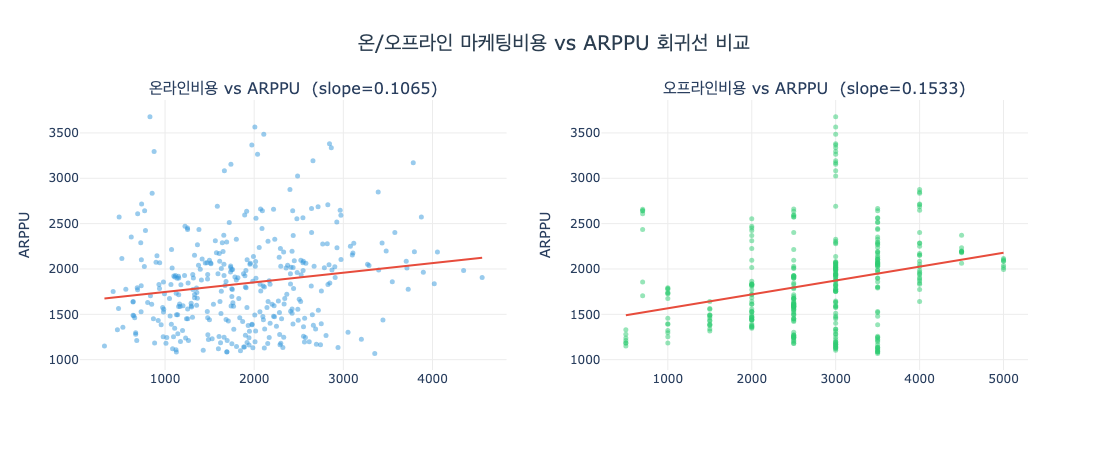

온라인 slope: 0.106532
오프라인 slope: 0.153336
→오프라인 마케팅이 ARPPU 향상에 더 효과적


In [39]:
slope_online,  intercept_online, *_ = stats.linregress(daily_mkt['온라인비용'],  daily_mkt['ARPPU'])
slope_offline, intercept_offline, *_ = stats.linregress(daily_mkt['오프라인비용'], daily_mkt['ARPPU'])

x_on = np.linspace(daily_mkt['온라인비용'].min(),  daily_mkt['온라인비용'].max(), 100)
x_off = np.linspace(daily_mkt['오프라인비용'].min(), daily_mkt['오프라인비용'].max(), 100)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f'온라인비용 vs ARPPU  (slope={slope_online:.4f})',
        f'오프라인비용 vs ARPPU  (slope={slope_offline:.4f})'
    ]
)

fig.add_trace(go.Scatter(
    x=daily_mkt['온라인비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#3498db', size=5, opacity=0.5), name='온라인'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=x_on, y=slope_online * x_on + intercept_online,
    mode='lines', line=dict(color='#e74c3c', width=2), name='온라인 회귀선'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_mkt['오프라인비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#2ecc71', size=5, opacity=0.5), name='오프라인'
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=x_off, y=slope_offline * x_off + intercept_offline,
    mode='lines', line=dict(color='#e74c3c', width=2), name='오프라인 회귀선'
), row=1, col=2)

fig.update_layout(
    title=dict(text='온/오프라인 마케팅비용 vs ARPPU 회귀선 비교', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', height=450, showlegend=False
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(title_text='ARPPU', gridcolor='#ececec')
fig.show()

better = '온라인' if slope_online > slope_offline else '오프라인'
print(f"온라인 slope: {slope_online:.6f}")
print(f"오프라인 slope: {slope_offline:.6f}")
print(f"→{better} 마케팅이 ARPPU 향상에 더 효과적")

---
## 7. 지역별 구매 패턴

고객지역별로 고객 수, 평균 구매횟수, 평균구매금액을 비교한다.  
고객 수와 구매금액이 모두 높은 지역은 집중 투자 우선순위가 명확한 핵심 타겟이다.

In [40]:
cust_summary = pd.read_sql(
    """
    SELECT
        고객ID,
        COUNT(DISTINCT 거래ID) AS 구매횟수,
        ROUND(SUM(세후금액), 0) AS 총구매금액,
        ROUND(SUM(세후금액) / COUNT(DISTINCT 거래ID), 2) AS 평균구매금액
    FROM orders_master
    GROUP BY 고객ID
    """,
    engine
)
cust_summary.head(3)

,고객ID,구매횟수,총구매금액,평균구매금액
0,USER_0000,1,25.0,24.98
1,USER_0001,31,14997.0,483.78
2,USER_0002,8,1492.0,186.55


In [41]:
region_summary = pd.read_sql(
    """
    SELECT
        고객지역,
        COUNT(DISTINCT 고객ID) AS 고객수,
        ROUND(AVG(구매횟수), 2) AS 평균구매횟수,
        ROUND(AVG(평균구매금액), 2) AS 평균구매금액
    FROM (
        SELECT
            고객지역,
            고객ID,
            COUNT(DISTINCT 거래ID) AS 구매횟수,
            ROUND(SUM(세후금액) / COUNT(DISTINCT 거래ID), 2) AS 평균구매금액
        FROM orders_master
        GROUP BY 고객지역, 고객ID
    ) cust
    GROUP BY 고객지역
    ORDER BY 평균구매금액 DESC
    """,
    engine
)
region_summary

,고객지역,고객수,평균구매횟수,평균구매금액
0,Washington DC,75,18.85,195.38
1,New Jersey,149,15.34,179.40
2,Chicago,456,20.34,171.60
3,California,464,17.34,167.40
4,New York,324,17.23,165.47


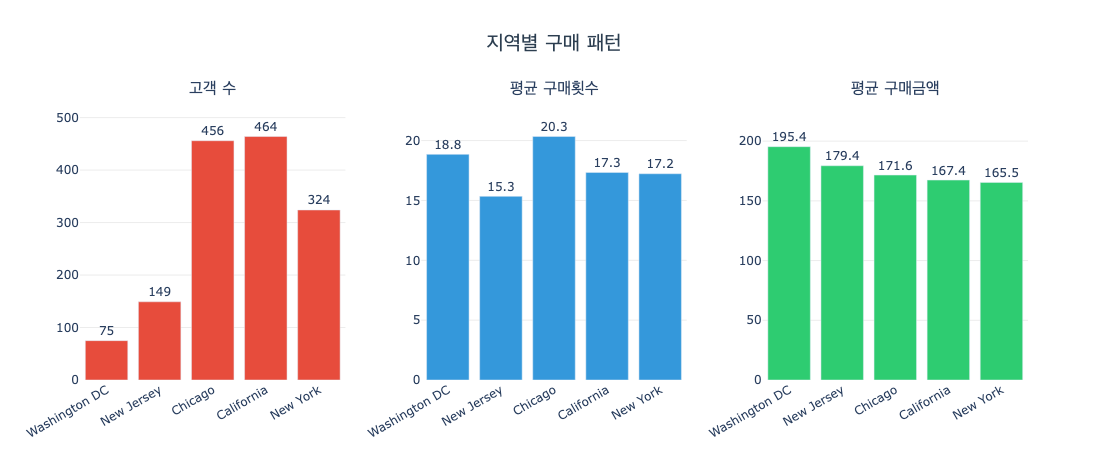

In [42]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('고객 수', '평균 구매횟수', '평균 구매금액'),
    horizontal_spacing=0.08
)

cols_colors = [
    ('고객수', '#e74c3c'),
    ('평균구매횟수', '#3498db'),
    ('평균구매금액', '#2ecc71'),
]

for i, (col, color) in enumerate(cols_colors, 1):
    fig.add_trace(go.Bar(
        x=region_summary['고객지역'],
        y=region_summary[col],
        text=region_summary[col].round(1),
        textposition='outside',
        marker_color=color, 
        showlegend=False
    ), row=1, col=i)

fig.update_layout(
    title=dict(
        text='지역별 구매 패턴',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white', height=460
)
for i in range(1, 4):
    fig.update_xaxes(tickangle=-30, row=1, col=i)
    fig.update_yaxes(gridcolor='#ececec', row=1, col=i)

fig.update_yaxes(range=[0, region_summary['고객수'].max() * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, region_summary['평균구매횟수'].max() * 1.15], row=1, col=2)
fig.update_yaxes(range=[0, region_summary['평균구매금액'].max() * 1.2], row=1, col=3)

fig.show()

---
## 8. 요일별 구매 패턴

요일별 일평균 거래건수와 평균 거래금액을 비교한다.  
특정 요일에 구매 활동이 집중되면 마케팅 집행 주기 설정에 활용할 수 있다.

In [43]:
dow_summary = pd.read_sql(
    """
    SELECT
        ELT(WEEKDAY(거래날짜)+1,
            'Mon','Tue','Wed','Thu','Fri','Sat','Sun') AS 거래요일,
        ROUND(COUNT(DISTINCT 거래ID) / COUNT(DISTINCT 거래날짜), 2) AS 일평균_거래건수,
        ROUND(SUM(세후금액) / COUNT(DISTINCT 거래ID), 2) AS 평균_거래금액
    FROM orders_master
    GROUP BY 거래요일, WEEKDAY(거래날짜)
    ORDER BY WEEKDAY(거래날짜)
    """,
    engine
)
dow_summary

,거래요일,일평균_거래건수,평균_거래금액
0,Mon,40.94,176.70
1,Tue,43.64,176.42
2,Wed,84.12,194.93
3,Thu,82.15,204.50
4,Fri,81.31,211.75
5,Sat,74.40,180.52
6,Sun,74.06,186.56


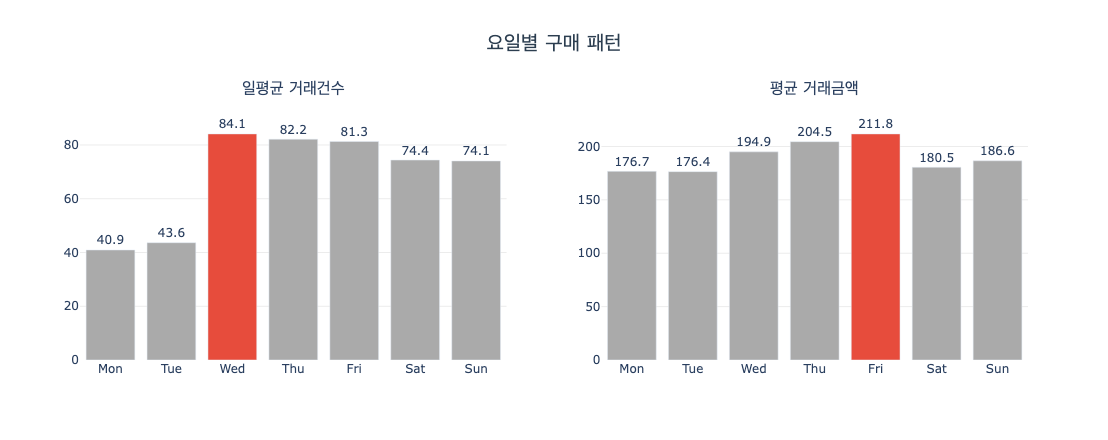

In [44]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('일평균 거래건수', '평균 거래금액'),
    horizontal_spacing=0.1
)

for i, col in enumerate(['일평균_거래건수', '평균_거래금액'], 1):
    max_day = dow_summary.loc[dow_summary[col].idxmax(), '거래요일']
    fig.add_trace(go.Bar(
        x=dow_summary['거래요일'],
        y=dow_summary[col],
        marker_color=[
            '#e74c3c' if d == max_day else '#aaaaaa'
            for d in dow_summary['거래요일']
        ],
        text=dow_summary[col].round(1),
        textposition='outside',
        showlegend=False
    ), row=1, col=i)

fig.update_layout(
    title=dict(
        text='요일별 구매 패턴',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white', height=440
)
for i in range(1, 3):
    fig.update_yaxes(gridcolor='#ececec', row=1, col=i)

fig.update_yaxes(range=[0, dow_summary['일평균_거래건수'].max() * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, dow_summary['평균_거래금액'].max() * 1.15], row=1, col=2)

fig.show()

---
## 9. 장바구니 분석

In [45]:
basket = pd.read_sql(
    """
    SELECT
        거래ID,
        COUNT(제품ID) AS 아이템수,
        COUNT(DISTINCT 제품카테고리) AS 카테고리수
    FROM orders_master
    GROUP BY 거래ID
    """,
    engine
)

cat_div = pd.read_sql(
    """
    SELECT
        고객ID,
        COUNT(DISTINCT 제품카테고리) AS 구매카테고리수
    FROM orders_master
    GROUP BY 고객ID
    """,
    engine
)

print(f"거래당 평균 아이템 수: {basket['아이템수'].mean():.2f}")
print(f"거래당 평균 카테고리 수: {basket['카테고리수'].mean():.2f}")
print(f"단일 아이템 거래 비중: {(basket['아이템수'] == 1).mean()*100:.1f}%")
print(f"\n고객별 평균 구매 카테고리 수: {cat_div['구매카테고리수'].mean():.2f}")

거래당 평균 아이템 수: 2.10
거래당 평균 카테고리 수: 1.36
단일 아이템 거래 비중: 58.5%

고객별 평균 구매 카테고리 수: 5.91


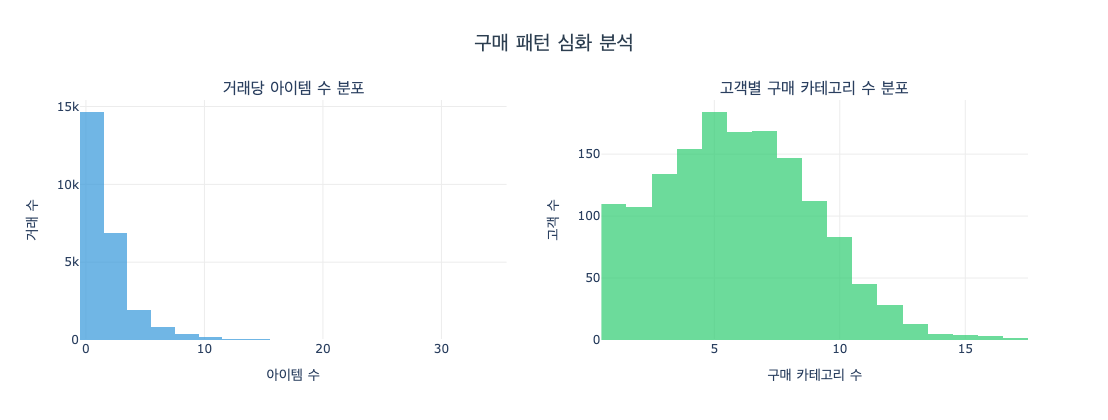

In [46]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('거래당 아이템 수 분포', '고객별 구매 카테고리 수 분포')
)

fig.add_trace(go.Histogram(
    x=basket['아이템수'], marker_color='#3498db', opacity=0.7,
    name='아이템수', nbinsx=20
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=cat_div['구매카테고리수'], marker_color='#2ecc71', opacity=0.7,
    name='카테고리수', nbinsx=18
), row=1, col=2)

fig.update_layout(
    title=dict(text='구매 패턴 심화 분석',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', showlegend=False, height=420
)

fig.update_xaxes(title_text='아이템 수', row=1, col=1, gridcolor='#ececec')
fig.update_xaxes(title_text='구매 카테고리 수', row=1, col=2, gridcolor='#ececec')
fig.update_yaxes(title_text='거래 수', row=1, col=1, gridcolor='#ececec')
fig.update_yaxes(title_text='고객 수', row=1, col=2, gridcolor='#ececec')

fig.show()

---
## 10. EDA 인사이트 요약

### 매출 구조
- **Nest-USA** 단일 카테고리가 전체 매출의 약 **54%** 차지 — 특정 카테고리 의존도가 매우 높음
- **Nest-USA**는 거래건수(11,626건)와 매출 모두 1위 — **Apparel**은 거래건수 2위(8,129건)이지만 매출 기여는 13% 수준으로, 거래량과 매출이 반드시 비례하지 않음
- 저단가 다빈도(Apparel, Office) vs 고단가 저빈도(Nest-USA, Nest) 구조 혼재 — 카테고리별 역할이 뚜렷이 다름

### 시간 패턴
- **11~12월** 매출이 연중 최고, **2월·5~6월**이 저점 — 계절성이 뚜렷
- **7월 ROI(101.97) 최고** — 마케팅 비용이 적은 달에 오히려 효율이 가장 우수
- 12월은 매출 최고이지만 ROI(80.55)는 평균 수준 — 비용도 함께 증가하기 때문

### 고객 구매 빈도
- 거래 건수 **중앙값 11건**, 평균 **18.1건**의 우편향 분포 — 75%의 고객이 23건 이하, 최대 327건의 헤비유저 소수가 평균을 끌어올리는 구조
- 이탈 고객 다수와 소수 헤비유저가 공존하는 전형적인 e-commerce 구매 패턴

### 고객 재방문 횟수
- 재방문 횟수(구매일 수 - 1) **중앙값 0.5**, 평균 **1.2회** — 거래 건수 평균(18.1건)과 큰 차이로, 대부분의 거래가 소수의 날에 집중됨을 의미
- 전체 고객의 1/4 이상이 **'단발성 구매'** 에 그친다. 25% 분위수가 0이라는 것은 초기 이탈률이 매우 높음을 시사
- 최대 **33일** — 거래건수 최대(327건) 대비 훨씬 낮아, 헤비유저도 하루에 여러 거래를 몰아서 하는 패턴

### 고객 인구통계
- 여성 고객이 전체 매출의 약 **62%** 기여 (고객 수: 여 934명 > 남 534명)
- **평균·중앙값 구매액은 남녀 거의 동일** — 매출 차이는 객단가가 아닌 고객 수에서 기인
- **25개월 이상** 장기 고객이 전체의 **53%(780명)** 로 가장 많고 구매빈도(18.88회)도 가장 높음
- **쿠폰 사용률은 가입기간 구간별 거의 동일** (33~34%) — 장기 고객도 쿠폰 의존도가 줄지 않음
- **13~24개월 구간**에서 평균 구매액(88.63)이 소폭 저하 — 초기 구매 열의가 식는 중간 단계 이탈 가능성

### 성별 구매 패턴
- **여성**: Apparel·Bags 등 패션·액세서리 카테고리가 거래건수 상위 — 반복 구매 빈도가 높음
- **남성**: Nest-USA·Office 등 고단가 카테고리 비중이 상대적으로 높음
- 카테고리별 구매금액 중앙값은 Nest-USA에서 성별 격차가 가장 크게 나타남 — 남성 고단가 집중 경향을 반영

### 쿠폰/할인
- 쿠폰 **Used** 고객의 평균 구매액(77)이 **Clicked**(98), **Not Used**(100)보다 낮음
  → 쿠폰이 저가 상품 전환에 더 많이 사용, 고가 상품 구매자는 쿠폰 없이도 구매하는 경향
- 할인율 높을수록 평균 구매액 감소 (10%: 87 → 20%: 75 → 30%: 69)

### 마케팅 비용
- 총매출 vs 온라인비용 **r=0.83**, 총매출 vs 오프라인비용 **r=0.72** — 두 채널 모두 매출과 강한 양의 상관
- 온라인비용 vs 오프라인비용 **r=0.88** — 계절 수요가 매출·비용을 동시에 끌어올리는 연동 구조
- **14일 윈도우 ARPPU** 기준 온라인/오프라인 회귀선 기울기 비교 → 채널별 효율 차이 확인

### 지역별 구매 패턴
- **Chicago·California** 2개 지역이 고객 수, 평균 구매횟수, 평균 구매금액 모두 상위권
- 전체 매출의 약 **66%** 가 이 두 지역에 집중 — 집중 투자 우선순위가 명확한 핵심 타겟

### 요일별 구매 패턴
- **수-금(Wed·Thu·Fri)** 일평균 거래건수(81-84건)·평균 거래금액(195-212)이 모두 최고 — 주중 중후반에 구매 활동 집중
- **금요일(Fri)** 평균 거래금액 211.75로 가장 높음 — 주말 직전 고단가 구매 경향
- **월-화(Mon·Tue)** 거래건수(41-44건)·평균 거래금액(176)이 모두 최저 — 주초 구매 공백 구간
- 주말(Sat·Sun)은 거래건수 74건으로 중간, 평균 거래금액(181-187)은 월-화보다 높음
- 수-금 집중 패턴을 활용해 주중 중후반에 마케팅 집행을 집중하면 비용 효율 개선 여지 있음

### 장바구니 분석
- 대부분의 거래가 단일 아이템으로 구성 — 크로스셀 기회 존재
- 고객별 구매 카테고리 수가 낮아 카테고리 다변화 여지가 있음

---

### 다음 분석 방향

EDA에서 확인된 패턴(카테고리 편중, 성별 구매 차이, 지역 집중, 쿠폰 효과)은 고객 개인 단위 분석으로 심화가 필요하다.

- **Retention 심화** — 코호트별 재구매율, 채널·카테고리·마케팅 비용에 따른 리텐션 차이 (`02_retention`)
- **RFM 세그먼테이션** — 등급별 쿠폰·카테고리·인구통계 패턴 비교, 등급별 마케팅 제언